# Track Clinical Data Drift & Survival Analysis

This notebook will analyzes the spatial, temporal, and conceptual drift of Out-of-Hospital Cardiac Arrests (OHCA) across a decade. 
* **Era 1:** 2010–2017 
* **Era 2:** 2018–2021

I will be comparing the two operation eras to determine if the volume and geographic hotspots of OHCAs have fundamentally shifted

# Install Libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Machine Learning Libraries
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Checking src directory

In [6]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[0]
print(SRC_DIRECTORY)

/Users/axlee/Desktop/Singhealth/AED-OHCA


# Import PAROS dataset

In [7]:
BASE_DATASET_PATH = Path(SRC_DIRECTORY)
BASE_DATASET_PATH = BASE_DATASET_PATH /"datasets"
print(BASE_DATASET_PATH)

/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets


In [8]:
read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/ohca_data/ohca_binary_complete.csv")
df = pd.read_csv(read_from_filepath)
df = df.drop(columns=['Unnamed: 0'])

# Checking columns of the dataset

In [9]:
df.columns

Index(['pln_area_n', 'subzone_n', 'year', 'month', 'incident_count',
       'ohca_binary', 'total', 'above_60_proportion',
       'male_chinese_proportion', 'female_chinese_proportion',
       'male_malays_proportion', 'female_malays_proportion',
       'male_indians_proportion', 'female_indians_proportion',
       'male_others_proportion', 'female_others_proportion',
       'business_1_encoding', 'business_2_encoding', 'business_park_encoding',
       'school_encoding', 'airport', 'is_residential'],
      dtype='object')

# Splitting the data into two comparison eras

In [10]:
# Split data into the two comparison eras
era1 = df[(df['year'] >= 2010) & (df['year'] <= 2017)]
era2 = df[(df['year'] >= 2018) & (df['year'] <= 2021)]

print(f"Era 1 (2010-2017) count: {len(era1)}")
print(f"Era 2 (2018-2021) count: {len(era2)}")

Era 1 (2010-2017) count: 28737
Era 2 (2018-2021) count: 14832


## 1. Temporal Drift (Volume Shift)
First, I look at the macro-level trend.

Has the total volume of cardiac arrests increased over the 11-year period? 

If the slope accelerates sharply in Era 2, it indicates a temporal drift that goes beyond standard historical averages.

### Group total incidents by year

In [12]:
yearly_incidents = df.groupby('year')['incident_count'].sum().reset_index()
display(yearly_incidents)

,year,incident_count
0,2010,1043.0
1,2011,1335.0
2,2012,1410.0
3,2013,1702.0
4,2014,1963.0
5,2015,2301.0
6,2016,2434.0
7,2017,2715.0
8,2018,2864.0
9,2019,3132.0


### Plotting

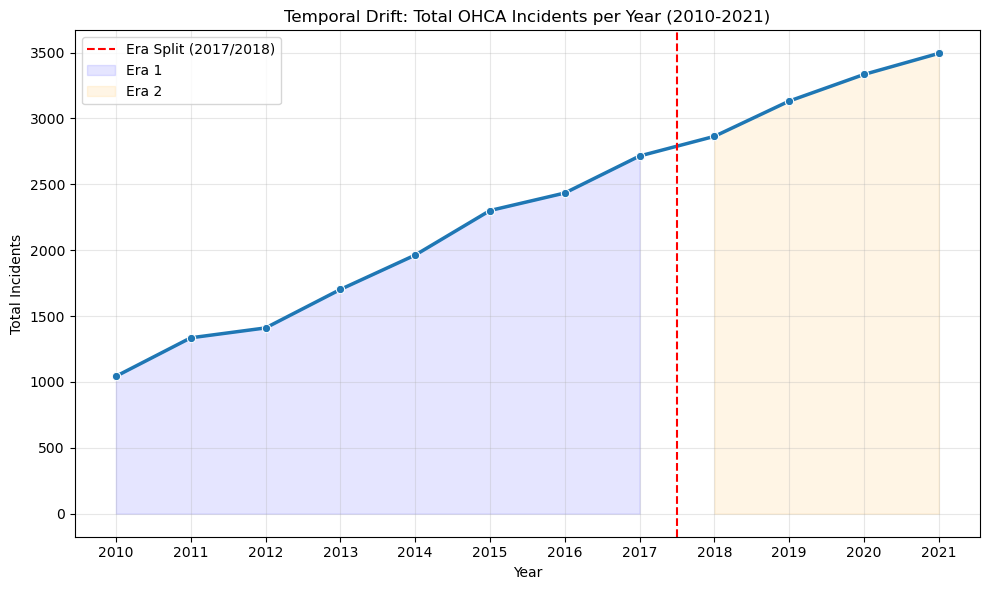

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_incidents, x='year', y='incident_count', marker='o', linewidth=2.5)

# Highlight Era 1 vs Era 2
plt.axvline(x=2017.5,
            color='red',
            linestyle='--',
            label='Era Split (2017/2018)')
plt.fill_between(yearly_incidents['year'],
                 0,
                 yearly_incidents['incident_count'], 
                 where=(yearly_incidents['year'] <= 2017),
                 alpha=0.1,
                 color='blue',
                 label='Era 1')
plt.fill_between(yearly_incidents['year'],
                 0,
                 yearly_incidents['incident_count'], 
                 where=(yearly_incidents['year'] >= 2018),
                 alpha=0.1,
                 color='orange',
                 label='Era 2')

plt.title('Temporal Drift: Total OHCA Incidents per Year (2010-2021)')
plt.xlabel('Year')
plt.ylabel('Total Incidents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(yearly_incidents['year'])
plt.tight_layout()
plt.show()

The graph reveals a severe increase in the raw volume of OHCA incidents over the 11-year period. 
* In 2010, the EMS system handled roughly 1,000 incidents. 
* By the end of Era 2 (2021), this number soared to approximately 3,500. 
* This is a **more than 300% increase in baseline volume**, indicating that the temporal drift is highly significant.

## 2. Spatial Incidence Drift (Hotspot Migration)
Next, I map the geographic drift.

By calculating the average annual incidents per subzone in Era 1 versus Era 2, I can isolate which specific neighborhoods have cooled down since , and which have emerged as severe new hotspots.

### # Calculate average annual incidents per subzone for Era 1 (8 years)

In [20]:
era1_subzones = era1.groupby('subzone_n')['incident_count'].sum() / 8
era1_subzones.name = 'era1_annual_avg'
display (era1_subzones.head())

subzone_n
admiralty           4.375
alexandra hill     12.000
alexandra north     0.500
aljunied           27.750
anak bukit          7.750
Name: era1_annual_avg, dtype: float64

### Calculate average annual incidents per subzone for Era 2 (4 years)

In [19]:
era2_subzones = era2.groupby('subzone_n')['incident_count'].sum() / 4
era2_subzones.name = 'era2_annual_avg'
display (era2_subzones.head())

subzone_n
admiralty           7.50
alexandra hill     21.00
alexandra north     0.50
aljunied           47.50
anak bukit         10.75
Name: era2_annual_avg, dtype: float64

### Merge and calculate the drift

In [21]:
spatial_drift = pd.concat([era1_subzones, era2_subzones], axis=1).fillna(0)
spatial_drift['absolute_change'] = spatial_drift['era2_annual_avg'] - spatial_drift['era1_annual_avg']
display(spatial_drift.head())

,era1_annual_avg,era2_annual_avg,absolute_change
subzone_n,,,
admiralty,4.375,7.50,3.125
alexandra hill,12.000,21.00,9.000
alexandra north,0.500,0.50,0.000
aljunied,27.750,47.50,19.750
anak bukit,7.750,10.75,3.000


### Get the top 10 subzones with the biggest increase in OHCAs

In [22]:
top_emerging_hotspots = spatial_drift.sort_values(by='absolute_change', ascending=False).head(10)
display(top_emerging_hotspots)

,era1_annual_avg,era2_annual_avg,absolute_change
subzone_n,,,
tampines east,55.250,100.50,45.250
central water catchment,3.250,41.00,37.750
bedok north,50.625,85.75,35.125
tampines west,31.250,59.00,27.750
yunnan,25.875,48.00,22.125
bedok south,25.000,46.50,21.500
hougang west,21.750,42.50,20.750
aljunied,27.750,47.50,19.750
fernvale,10.750,30.25,19.500


### Barplot to see the hotspots

/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_9817/2146043773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_emerging_hotspots.index,


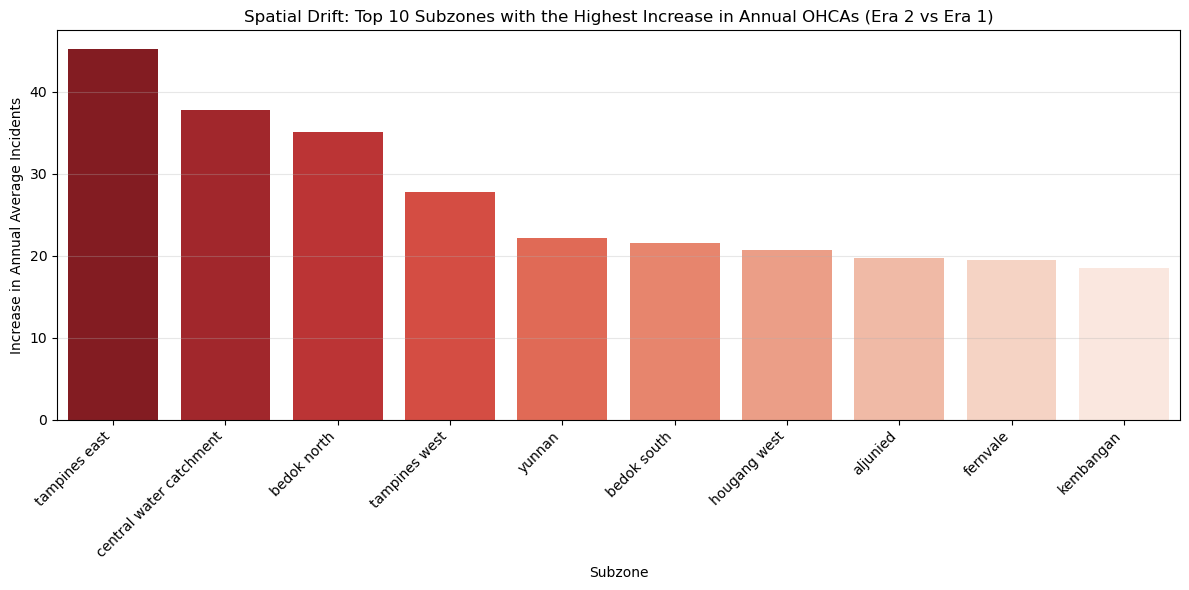

Top 5 Emerging Hotspots Data:
                         era1_annual_avg  era2_annual_avg  absolute_change
subzone_n                                                                 
tampines east                     55.250           100.50           45.250
central water catchment            3.250            41.00           37.750
bedok north                       50.625            85.75           35.125
tampines west                     31.250            59.00           27.750
yunnan                            25.875            48.00           22.125


In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(x=top_emerging_hotspots.index,
            y=top_emerging_hotspots['absolute_change'],
            palette='Reds_r')
plt.title('Spatial Drift: Top 10 Subzones with the Highest Increase in Annual OHCAs (Era 2 vs Era 1)')

plt.xlabel('Subzone')
plt.ylabel('Increase in Annual Average Incidents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Emerging Hotspots Data:")
print(top_emerging_hotspots[['era1_annual_avg', 'era2_annual_avg', 'absolute_change']].head())

The bar chart shows that this massive surge in volume was not distributed equally across the map. Specific neighborhoods absorbed the brunt of the impact.

* **Tampines East** emerged as the single largest new hotspot, experiencing an average increase of over 45 cardiac arrests *per year* in Era 2 compared to its Era 1 baseline.

* There is a distinct geographic clustering in the East: Tampines East, Bedok North, Tampines West, and Bedok South all make the top 10.

* This may indicate that resource allocation (like ambulance staging) needs to be heavily biased toward these expanding eastern residential zones.

# Machine Learning Concept Drift


To test for concept drift, a Poisson Regressor (the standard algorithm for predicting count data) will be used entirely on Era 1 (2010-2017). I will be using demographic features like the proportion of seniors and residential zoning to teach the model how to predict `incident_count`.

The model will be then forced to predict Era 2 (2018-2021).

If the model severely under-predicts the actual incidents, it proves that the mathematical relationship between demographics and cardiac arrests has fundamentally shifted (drifted) in the modern era.

### Defining the predictive features and target

In [29]:
era1.columns

Index(['pln_area_n', 'subzone_n', 'year', 'month', 'incident_count',
       'ohca_binary', 'total', 'above_60_proportion',
       'male_chinese_proportion', 'female_chinese_proportion',
       'male_malays_proportion', 'female_malays_proportion',
       'male_indians_proportion', 'female_indians_proportion',
       'male_others_proportion', 'female_others_proportion',
       'business_1_encoding', 'business_2_encoding', 'business_park_encoding',
       'school_encoding', 'airport', 'is_residential'],
      dtype='object')

In [30]:
features = ['above_60_proportion', 'is_residential', 'male_chinese_proportion', 
            'female_chinese_proportion', 'male_malays_proportion', 'female_malays_proportion',
            'male_indians_proportion', 'female_indians_proportion', 'male_others_proportion', 'female_others_proportion']
target = 'incident_count'

display(features)

['above_60_proportion',
 'is_residential',
 'male_chinese_proportion',
 'female_chinese_proportion',
 'male_malays_proportion',
 'female_malays_proportion',
 'male_indians_proportion',
 'female_indians_proportion',
 'male_others_proportion',
 'female_others_proportion']

### Clean the data to ensure no NaN in the features

In [32]:
era1_ml = era1.dropna(subset=features + [target])
era2_ml = era2.dropna(subset=features + [target])

display(era1_ml.head())

,pln_area_n,subzone_n,year,month,incident_count,ohca_binary,total,above_60_proportion,male_chinese_proportion,female_chinese_proportion,...,male_indians_proportion,female_indians_proportion,male_others_proportion,female_others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,school_encoding,airport,is_residential
0,ang mo kio,ang mo kio town centre,2010,4,0.0,0,18757,13.85616,41.739084,43.546409,...,2.761636,3.01754,1.450125,1.658048,0,0,0,0,0,1
1,ang mo kio,ang mo kio town centre,2010,5,1.0,1,18757,13.85616,41.739084,43.546409,...,2.761636,3.01754,1.450125,1.658048,0,0,0,0,0,1
2,ang mo kio,ang mo kio town centre,2010,6,0.0,0,18757,13.85616,41.739084,43.546409,...,2.761636,3.01754,1.450125,1.658048,0,0,0,0,0,1
3,ang mo kio,ang mo kio town centre,2010,7,2.0,1,18757,13.85616,41.739084,43.546409,...,2.761636,3.01754,1.450125,1.658048,0,0,0,0,0,1
4,ang mo kio,ang mo kio town centre,2010,8,0.0,0,18757,13.85616,41.739084,43.546409,...,2.761636,3.01754,1.450125,1.658048,0,0,0,0,0,1


### Creating X_Train, Y_Train, X_Test, Y_Test

In [34]:
X_train = era1_ml[features]
y_train = era1_ml[target]

X_test = era2_ml[features]
y_test = era2_ml[target]

display(X_train.head())

,above_60_proportion,is_residential,male_chinese_proportion,female_chinese_proportion,male_malays_proportion,female_malays_proportion,male_indians_proportion,female_indians_proportion,male_others_proportion,female_others_proportion
0,13.85616,1,41.739084,43.546409,2.377779,2.798955,2.761636,3.01754,1.450125,1.658048
1,13.85616,1,41.739084,43.546409,2.377779,2.798955,2.761636,3.01754,1.450125,1.658048
2,13.85616,1,41.739084,43.546409,2.377779,2.798955,2.761636,3.01754,1.450125,1.658048
3,13.85616,1,41.739084,43.546409,2.377779,2.798955,2.761636,3.01754,1.450125,1.658048
4,13.85616,1,41.739084,43.546409,2.377779,2.798955,2.761636,3.01754,1.450125,1.658048


### Train Poisson Regressor on Era 1 data only

In [37]:
model = PoissonRegressor()
model.fit(X_train, y_train)

# Testing the model on Era 1 - Baseline checking

era1_predictions = model.predict(X_train)
era1_mae = mean_absolute_error(y_train, era1_predictions)

# Testing the model on Era 2 - Drift checking

era2_predictions = model.predict(X_test)
era2_mae = mean_absolute_error(y_test, era2_predictions)

print(f"Era 1 Baseline Error (MAE): {era1_mae:.2f} incidents per subzone")
print(f"Era 2 Prediction Error (MAE): {era2_mae:.2f} incidents per subzone")

Era 1 Baseline Error (MAE): 0.58 incidents per subzone
Era 2 Prediction Error (MAE): 0.79 incidents per subzone


### Calculating the overall prediction gap

In [42]:
total_actual_era2 = y_test.sum()
total_predicted_era2 = era2_predictions.sum()
gap = total_actual_era2 - total_predicted_era2
percentage_gap = (gap / total_actual_era2) * 100

print(f"\nTotal Actual Era 2 Incidents: {total_actual_era2:.0f}")
print(f"Total Predicted Era 2 Incidents (based on Era 1 rules): {total_predicted_era2:.0f}")
print(f"Model Under-prediction Gap: {gap:.0f} incidents")
print(f"Percentage Under-prediction: {percentage_gap:.2f}%")



Total Actual Era 2 Incidents: 12808
Total Predicted Era 2 Incidents (based on Era 1 rules): 8425
Model Under-prediction Gap: 4383 incidents
Percentage Under-prediction: 34.22%


### Visualizing the drift

/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_9817/2565274008.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Actual Era 2 Incidents',


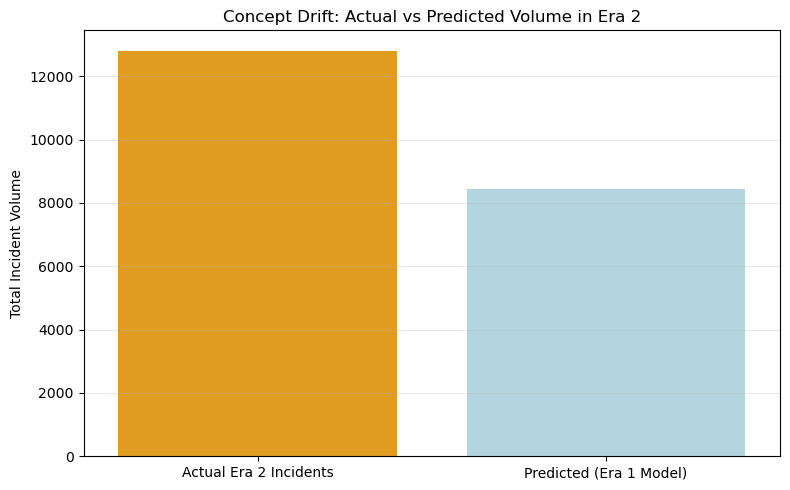

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(x=['Actual Era 2 Incidents',
               'Predicted (Era 1 Model)'], 
            y=[total_actual_era2, total_predicted_era2], 
            palette=['orange', 'lightblue'])

plt.title('Concept Drift: Actual vs Predicted Volume in Era 2')
plt.ylabel('Total Incident Volume')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation of the results


The Poisson regression model confirms  that the nature of Out-of-Hospital Cardiac Arrests (OHCA) has fundamentally shifted. 

### 1. The Breakdown of Historical Rules
The machine learning model to understand the relationship between urban demographics (e.g., aging populations, residential zoning) and OHCA volume using data purely from Era 1 (2010–2017). 
* When asked to predict Era 2 (2018–2021) using those same demographic rules, the model expected **8,425** incidents.
* In reality, Era 2 experienced **12,808** incidents.
* The model failed to predict **4,383** cardiac arrests—meaning nearly **34% of the modern incident volume cannot be explained by historical demographic trends alone**.

### 2. What caused Concept Drift?
This massive under-prediction proves that "Concept Drift" has occurred. Some potential reasons I could think off was:
* **The COVID-19 Pandemic:** Era 2 includes 2020 and 2021, where the pandemic caused severe cascading health effects, delayed medical interventions, and increased at-home emergencies.
* **Protocol & Reporting Changes:** There might be changes in how 995 dispatchers categorize calls or increased public use of AEDs could lead to more incidents being officially recorded as OHCAs.
* **Urban Density & Lifestyle:** Rapid shifts in population density, sedentary lifestyles, or post-pandemic working-from-home arrangements heavily concentrated incidents in residential subzones (like Tampines and Bedok) far beyond what linear aging models would predict.

### 3. Conclusion and Link to Spatial Simulation
This Concept Drift explains the exact system failure we observed in the NetLogo Spatial Simulation (Track 1). The EMS zoning and resource allocations were originally designed for the "Era 1 rules" (low lambda, steady volume). Because the modern era has drifted so aggressively—generating over 4,000 unexpected emergencies—the ambulance system reaches its saturation "elbow" much faster, resulting in the exponential spike in patient transport times.